# UNIVERSIDAD ICESI
# MAESTRIA EN  IA APLICADA
# Trabajo 2
## Nombres:

#### Angelica Maria Mayor
#### Diego Agudelo
#### Freddy Mauricio Gutierrez
#### Carlos Alberto Martinez Ramirez
#### Wilman Quiñonez


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion2/2-nlp-with-lstm.ipynb)

En este notebook implementaremos un clasificador de noticias en español utilizando la arquitectura de red LSTM. La idea es tener un punto de referencia para comparar cuando observemos la parte de transformers, por lo que utilizaremos el mismo dataset y tarea de ejemplo. Utilizarémos las utilidades de tokenización de huggingface transformers para ayudarnos con esta tarea.

El dataset contiene lo siguiente:


| Propriedad            | Descripción                                                                 |
|------------------|-----------------------------------------------------------------------------|
| **`review_id`**             |  ID único de la reseña.                          |
| **`reviewer_id`**      |   ID del usuario que dejó la reseña.                |
| **`review_title`**          |  Título de la reseña.    |
| **`review_body`**        |  Texto completo de la reseña.     |                            |
| **`star_rating`**        |  Puntuación otorgada (1–5 estrellas).      |                           |
| **`language`**        |  Idioma de la reseña (en este caso siempre "en")     |
| **`product_category`**        |  Categoría del producto (ej: libros, electrónica, etc.)      |
| **`review_date`**        |  Fecha en que se dejó la reseña.     |


📐 Tamaño aproximado El dataset completo multilingüe contiene más de 200 millones de reseñas en distintos idiomas. La versión en inglés ("en") sigue siendo enorme: millones de reseñas en varias categorías de productos.

#### Referencias

- [Long Short-Term Memory](https://www.researchgate.net/publication/13853244_Long_Short-Term_Memory#fullTextFileContent)

In [1]:
# Este comando de shell instala la librería `gensim`.
# `gensim` es una librería de Python para modelado de temas, indexación de documentos
# y recuperación de similitud con grandes corpus.
# El signo de exclamación `!` al inicio indica que este es un comando de shell
# que se ejecutará directamente en el entorno.
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 12.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requir

In [13]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

# Obtiene una lista de los nombres de los paquetes instalados en el entorno actual.
installed_packages = [package.key for package in pkg_resources.working_set]

# Verifica si 'google-colab' está en la lista de paquetes instalados.
# Si está presente, significa que el código se está ejecutando en Google Colab.
# La variable `IN_COLAB` será True si está en Colab y False en caso contrario.
IN_COLAB = 'google-colab' in installed_packages

In [17]:
#📌 INSTALACIÓN Y ACTUALIZACIÓN DE HERRAMIENTAS
#✅ Actualizar el sistema y paquetes (apt-get update).
#✅ Instalar Python 3.10 y librerías asociadas (distutils, lib2to3).
#✅ Configurar alternativas de Python para que el intérprete por defecto.
#✅ Instalar PyTorch Lightning y datasets.

#!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

## Dataset   

In [18]:
# Importa la función load_dataset de la librería datasets de Hugging Face.
# Esta librería es útil para cargar y trabajar con una amplia variedad de datasets,
# especialmente aquellos utilizados en procesamiento de lenguaje natural (NLP).
from datasets import load_dataset

# Carga el dataset específico "neonwatty/amazon_reviews_multi".
# El primer argumento es el nombre del dataset en el Hub de Hugging Face.
# El segundo argumento "en" especifica la configuración o subconjunto del dataset a cargar,
# en este caso, la versión en inglés.
# El tercer argumento split="train" indica que solo queremos cargar el split de entrenamiento
# del dataset. Otros splits comunes son "validation" y "test".
# El dataset cargado se asigna a la variable 'dataset'.
dataset = load_dataset("neonwatty/amazon_reviews_multi", "en", split="train")

# Imprime el objeto dataset. Esto muestra información resumida sobre el dataset cargado,
# como las características disponibles (columnas) y el número de filas (ejemplos).
# Es útil para verificar que el dataset se cargó correctamente y entender su estructura.
dataset

Dataset({
    features: ['review_title', 'review_body', 'review_id', 'stars'],
    num_rows: 200000
})

In [19]:
dataset[1]

{'review_title': 'Not use able',
 'review_body': 'the cabinet dot were all detached from backing... got me',
 'review_id': 'en_0690095',
 'stars': 1}

Se realiza el analisis descriptivo:



In [20]:
import numpy as np

# Calculamos la longitud en tokens (palabras simples separadas por espacios)
# Itera sobre cada fila en el 'dataset'.
# Para cada fila, accede al contenido de la columna 'review_body'.
# Divide el texto de 'review_body' en palabras usando .split() (separando por espacios).
# Calcula la longitud de la lista resultante de palabras.
# Almacena estas longitudes en una lista llamada 'text_lengths'.
text_lengths = [len(row['review_body'].split()) for row in dataset]

# Imprime la longitud del texto más corto encontrado en el dataset.
print(f"Texto más corto: {min(text_lengths)} tokens")
# Imprime la longitud del texto más largo encontrado en el dataset.
print(f"Texto más largo: {max(text_lengths)} tokens")
# Calcula la longitud promedio de los textos usando numpy.mean() y la imprime formateada a dos decimales.
print(f"Longitud promedio: {np.mean(text_lengths):.2f} tokens")

# Percentiles
# Itera sobre una lista de percentiles (50, 75, 90, 95, 99).
for p in [50, 75, 90, 95, 99]:
    # Calcula el percentil 'p' de la lista 'text_lengths' usando numpy.percentile()
    # e imprime el resultado. Esto muestra la distribución de las longitudes.
    print(f"P{p}: {np.percentile(text_lengths, p)} tokens")

Texto más corto: 1 tokens
Texto más largo: 769 tokens
Longitud promedio: 34.11 tokens
P50: 24.0 tokens
P75: 44.0 tokens
P90: 72.0 tokens
P95: 96.0 tokens
P99: 165.0 tokens


In [5]:
import plotly.express as px

# Suponiendo que ya calculaste text_lengths así:
# text_lengths = [len(row['review_body'].split()) for row in dataset]

# Crear boxplot horizontal
fig = px.box(
    x=text_lengths,  # eje horizontal con las longitudes
    orientation="h", # orientación horizontal del boxplot
    labels={"x": "Longitud de reseña (tokens)"}, # etiqueta para el eje X
    title="Distribución de longitudes de reseñas (tokens)" # título del gráfico
)

# Mostrar el gráfico
fig.show()

Se analizaron 200,000 reseñas.

La longitud promedio es de 34 tokens, con una desviación estándar también de ~34 → hay bastante variabilidad.

La reseña más corta tiene 1 token y la más larga llega hasta 769 tokens.

Percentiles:

25% de las reseñas tienen ≤ 12 tokens.

50% (mediana) tienen ≤ 24 tokens.

75% tienen ≤ 44 tokens.

In [6]:
import pandas as pd

# Convertir lista a Series de Pandas
# Convertimos la lista `text_lengths` (que contiene la longitud de cada reseña)
# a una Serie de Pandas. Una Serie es una estructura de datos unidimensional.
text_lengths_series = pd.Series(text_lengths)

# Usar describe()
# El método `.describe()` de una Serie de Pandas calcula y muestra estadísticas
# descriptivas como la cuenta total, el promedio, la desviación estándar,
# los valores mínimo y máximo, y los cuartiles (25%, 50%, 75%).
# Esto proporciona un resumen rápido de la distribución de las longitudes de las reseñas.
print(text_lengths_series.describe())

count    200000.000000
mean         34.114000
std          34.201068
min           1.000000
25%          12.000000
50%          24.000000
75%          44.000000
max         769.000000
dtype: float64


Se calcula las palabras unicas en el dataset, que sera utilizado mas adelante

In [7]:
from collections import Counter

# Inicializa un objeto Counter para almacenar el recuento de cada token.
token_counts = Counter()

# Itera sobre cada fila en el objeto 'dataset'.
for row in dataset:   # dataset es el HuggingFace Dataset
    # Concatena el título y el cuerpo de la reseña, los convierte a minúsculas
    # y los asigna a la variable 'text'. Esto asegura uniformidad.
    text = (row['review_title'] + " " + row['review_body']).lower()
    # Divide el texto en palabras (tokens) usando el espacio como delimitador.
    # Esto crea una lista de tokens para cada reseña.
    tokens = text.split()   # o tu propio tokenizador si ya lo definiste
    # Actualiza el contador 'token_counts' con los tokens de la reseña actual.
    # Esto incrementa el recuento de cada token encontrado.
    token_counts.update(tokens)

# Calcula el número de palabras únicas encontradas en todo el dataset
# obteniendo la longitud de las claves (tokens únicos) en el contador.
num_unique_words = len(token_counts)
# Imprime el número total de palabras únicas.
print("Palabras únicas en el dataset:", num_unique_words)

# ejemplo: mostrar algunas de las palabras únicas y sus recuentos
# Convierte el contador a una lista de tuplas (token, count) y muestra las primeras 20.
print(list(token_counts.items())[:20])

Palabras únicas en el dataset: 137303
[("i'll", 1705), ('spend', 1018), ('twice', 1093), ('the', 367051), ('amount', 1407), ('of', 95069), ('time', 12173), ('boxing', 35), ('up', 19119), ('whole', 1895), ('useless', 864), ('thing', 4692), ('and', 200517), ('send', 2083), ('it', 181608), ('back', 9453), ('with', 53611), ('a', 180143), ('1-star', 12), ('review', 2154)]


## Tokenizador

Este código construye un vocabulario limitado (40k palabras) a partir de las reseñas, reservando [PAD] y [UNK].

[PAD] (padding): se usa para rellenar las secuencias más cortas y que todas tengan la misma longitud.

[UNK] (unknown): representa palabras fuera del vocabulario (OOV) que no fueron incluidas en las 40k más frecuentes.

In [21]:
import re
from collections import Counter

def simple_tokenizer(text):
    # Convierte todo el texto a minúsculas para asegurar consistencia.
    text = text.lower()
    # Usa una expresión regular para encontrar secuencias de letras (incluyendo acentos y 'ñ')
    # y reemplazar cualquier otro carácter con un espacio. Esto elimina puntuación, números, etc.
    text = re.sub(r"[^a-záéíóúüñ]+", " ", text)
    # Elimina espacios al inicio y al final del texto resultante, y luego divide
    # el texto en una lista de palabras (tokens) usando los espacios como delimitadores.
    return text.strip().split()

# Construimos el vocabulario a partir de conjunto de datos.
token_counts = Counter() # Inicializa un contador para llevar el recuento de cada token.
for text in dataset["review_body"]: # Itera sobre el texto de la columna 'review_body' en el dataset.
    token_counts.update(simple_tokenizer(text)) # Tokeniza el texto de cada reseña y actualiza el contador.

# 50k-2 porque necesitamos reservar espacio para los dos tokens especiales
# Obtiene los tokens más frecuentes del contador y los almacena en una lista.
# Limita la lista a los 40000 tokens más frecuentes, reservando 2 espacios para [PAD] y [UNK].
top_n_tokens = list(token_counts.keys())[:40000-2]
# Inicializa el diccionario de vocabulario con los tokens especiales [PAD] y [UNK]
# asignándoles los IDs 0 y 1 respectivamente.
vocab = {"[PAD]": 0, "[UNK]": 1}
# Itera sobre los tokens más frecuentes.
for token in top_n_tokens:
    vocab[token] = len(vocab) # Asigna un ID secuencial a cada token, empezando después de los especiales.

# Define una función para tokenizar un texto dado y convertirlo a una secuencia de IDs.
def tokenize_text(text, max_length=50):
    tokens = simple_tokenizer(text) # Tokeniza el texto de entrada.
    # Convierte cada token a su ID correspondiente usando el diccionario 'vocab'.
    # Si un token no está en el vocabulario (es una palabra desconocida), le asigna el ID de [UNK].
    # Trunca la lista de IDs si excede la 'max_length'.
    ids = [vocab.get(tok, vocab["[UNK]"]) for tok in tokens[:max_length]]
    # Rellena la lista de IDs con el ID de [PAD] hasta alcanzar la 'max_length'.
    ids += [vocab["[PAD]"]] * (max_length - len(ids))
    return ids # Devuelve la lista de IDs (representación numérica del texto).

In [22]:
print(f"Vocabulario: {len(vocab)} tokens")
print("Primeros 15 tokens:")
print(f"{top_n_tokens[:15]}")
print("15 tokens de en medio:")
print(f"{top_n_tokens[1000:1015]}")
print("Últimos 15 tokens:")
print(f"{top_n_tokens[-15:]}")

Vocabulario: 40000 tokens
Primeros 15 tokens:
['arrived', 'broken', 'manufacturer', 'defect', 'two', 'of', 'the', 'legs', 'base', 'were', 'not', 'completely', 'formed', 'so', 'there']
15 tokens de en medio:
['five', 'minutes', 'compatible', 'active', 'land', 'dial', 'tone', 'bottles', 'intention', 'mixing', 'essential', 'oils', 'spray', 'leak', 'frequently']
Últimos 15 tokens:
['inadvisable', 'thinsulate', 'unmasking', 'kylo', 'remoter', 'littke', 'opp', 'bayliner', 'marches', 'guernsey', 'propylene', 'glycol', 'scenic', 'catheters', 'heartland']


In [23]:
# Llama a la función `tokenize_text` con el texto de ejemplo "hello active"
# y especifica una longitud máxima de secuencia de 8.
# La función tokenizará el texto, lo convertirá a una secuencia de IDs numéricos
# basados en el vocabulario preconstruido y aplicará relleno ([PAD]) si es necesario
# para alcanzar la longitud máxima especificada.
tokenized = tokenize_text("hello active", max_length=8)
# Imprime la lista resultante de IDs numéricos.
# Esto muestra la representación numérica del texto de entrada después de la tokenización y el relleno.
tokenized

[3780, 1005, 0, 0, 0, 0, 0, 0]

In [24]:
# Crea un diccionario que mapea los IDs de los tokens a los tokens (palabras).
# Esto se hace invirtiendo el diccionario `vocab`, donde las claves eran los tokens
# y los valores eran sus IDs. Ahora las claves son los IDs y los valores son los tokens.
id_2_token = {v: k for k, v in vocab.items()}

# Convierte la secuencia de IDs tokenizados de nuevo a tokens (palabras)
# utilizando el diccionario `id_2_token`.
# Itera sobre cada ID en la lista `tokenized` (la salida de la función `tokenize_text`).
# Para cada ID, busca el token correspondiente en el diccionario `id_2_token`.
# Esto resulta en una lista de tokens (palabras) que representan la secuencia tokenizada original.
[id_2_token[token] for token in tokenized]

['hello', 'active', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

## Pytorch

In [25]:
import numpy as np

# Usa numpy.unique para encontrar los valores únicos en la columna 'stars' del dataset.
# Esto nos da la lista de posibles calificaciones de estrellas (ej. [1, 2, 3, 4, 5]).
# enumerate() asigna un índice numérico (empezando desde 0) a cada valor único.
# dict() convierte este resultado en un diccionario donde las claves son los índices
# (0, 1, 2, 3, 4) y los valores son las calificaciones de estrellas correspondientes
# (1, 2, 3, 4, 5). Este diccionario mapea un ID numérico a una clase de estrella.
dict(enumerate(np.unique(dataset[:]['stars'])))

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5}

Este código prepara reseñas de Amazon para modelos de PyTorch, convirtiendo el texto en secuencias de tokens y las estrellas en etiquetas numéricas.
Esto es lo que necesitas para luego entrenar una LSTM

In [26]:
import torch
import numpy as np
from typing import Tuple, Dict
from torch.utils.data import Dataset

class amazon_dataset(Dataset):
    # El constructor inicializa el dataset personalizado.
    # Recibe un tokenizador (función), el dataset original de Hugging Face y la longitud máxima de secuencia.
    def __init__(self, tokenizer, dataset, seq_length: int = 128):
        # Almacena el tokenizador, el dataset original y la longitud máxima.
        self.tokenizer = tokenizer
        self.dataset = dataset
        self.seq_length = seq_length
        # Definimos estos dos mapas para facilitarnos la tarea
        # de traducir de nombres de categoría a ids de categoría.
        # id_2_class_map: Mapea IDs numéricos (0, 1, 2, 3, 4) a las clases originales de estrellas (1, 2, 3, 4, 5).
        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['stars'])))
        # class_2_id_map: Mapea las clases originales de estrellas (1, 2, 3, 4, 5) a IDs numéricos (0, 1, 2, 3, 4).
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        # Almacena el número total de clases (5 en este caso).
        self.num_classes = len(self.id_2_class_map)

    # Este método es fundamental para PyTorch Datasets y define cómo obtener un elemento individual.
    # Recibe un índice y devuelve un diccionario con los datos de entrada y la etiqueta.
    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        # Obtiene el texto de la reseña y la calificación de estrellas del dataset original por índice.
        text, y = self.dataset[index]['review_body'], self.dataset[index]['stars']
        # Convierte la calificación de estrellas a su ID numérico usando el mapa.
        y = self.class_2_id_map[y]
        # Tokeniza el texto de la reseña, limita la longitud y lo convierte a un tensor de PyTorch.
        data = {'input_ids': torch.tensor(self.tokenizer(text, max_length=self.seq_length))}
        # Convierte el ID numérico de la etiqueta a un tensor de PyTorch y lo añade al diccionario de datos.
        data['y'] = torch.tensor(y)
        # Devuelve el diccionario con los datos preparados.
        return data

    # Este método es requerido para PyTorch Datasets y devuelve el número total de elementos en el dataset.
    def __len__(self):
        # Retorna la longitud del dataset original.
        return len(self.dataset)

In [28]:
max_len = 128
# Instancia la clase `amazon_dataset`.
# Pasa la función `tokenize_text` como el tokenizador,
# el objeto `dataset` de Hugging Face como los datos crudos,
# y `max_len` como la longitud máxima de la secuencia.
data_amazon = amazon_dataset(tokenize_text, dataset, seq_length=max_len)
# Afirma (verifica) que la longitud de la instancia `data_amazon`
# es igual a la longitud del dataset original. Si no son iguales,
# el programa se detendrá con un AssertionError.
assert len(data_amazon) == len(dataset)

In [29]:
data_amazon[1]

{'input_ids': tensor([ 8, 86, 87, 11, 88, 89, 90, 91, 51, 74,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0]),
 'y': tensor(0)}

Este código toma el dataset de reseñas de Amazon (data_amazon), lo divide en conjuntos de entrenamiento, validación y prueba de forma estratificada, y genera los correspondientes DataLoaders que se utilizan para alimentar el modelo durante las fases de entrenamiento, validación y evaluación. Lo cual lo hace estratificado para no tener ningun incovenientes de balanceo.

In [30]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

# 1) saca las labels del dataset PyTorch (data_amazon[i] -> dict con 'y')
labels = [int(data_amazon[i]['y']) for i in range(len(data_amazon))]
idx = list(range(len(data_amazon)))

# 2) split train vs temp (val+test) estratificado
idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx, labels, test_size=0.2, random_state=42, stratify=labels
)

# 3) split temp a val/test estratificado
idx_val, idx_test, _, _ = train_test_split(
    idx_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

train_dataset = Subset(data_amazon, idx_train)
val_dataset   = Subset(data_amazon, idx_val)
test_dataset  = Subset(data_amazon, idx_test)

batch_size = 128 if IN_COLAB else 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

In [31]:
train_loader.dataset[0]


{'input_ids': tensor([ 507,  451,   64, 1391, 4130,  103,    8, 1182,   23,  526,  331,   53,
         1467,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]),
 'y': tensor(4)}

### Modelo BASELINE
Se construye un modelo baseline utilizando representaciones tradicionales (Word2Vec y TF-IDF) con el objetivo de establecer un punto de comparación y evaluar posteriormente si una arquitectura basada en LSTM puede ofrecer un mejor desempeño


[Modelo de multinomial-TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html)

Ejemplo: Cute and durable. Cute, good quality, packaged differently than the ones I’ve seen in stores. ... 4
Tamaños: 160000 20000 20000

TF-IDF + Logistic Regression | Val Accuracy: 0.6049

              precision    recall  f1-score   support

           0     0.6680    0.7017    0.6845      4000
           1     0.5003    0.4938    0.4970      4000
           2     0.5094    0.4828    0.4957      4000
           3     0.5886    0.5573    0.5725      4000
           4     0.7388    0.7890    0.7631      4000

    accuracy                         0.6049     20000
   macro avg     0.6010    0.6049    0.6025     20000
weighted avg     0.6010    0.6049    0.6025     20000



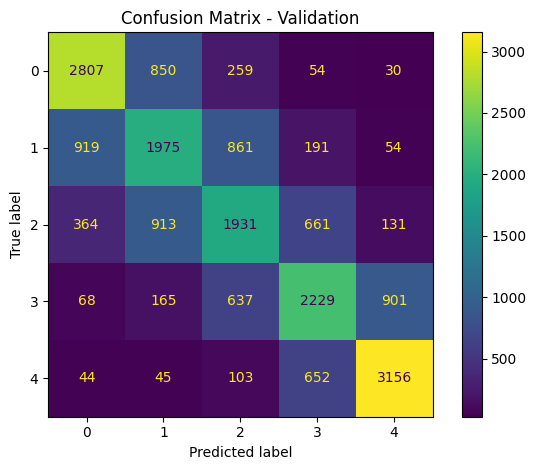

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Esta función auxiliar desciende a través de atributos '.dataset'
# para encontrar el dataset base original (por ejemplo, un Hugging Face Dataset)
# que contiene los datos brutos de texto.
def _unwrap_base_dataset(ds):
    """Desciende por atributos .dataset hasta llegar al dataset base (HF Dataset)."""
    base = ds
    # ds puede ser tu CustomDataset envuelto por Subset; vamos bajando mientras exista .dataset
    while hasattr(base, "dataset"):
        base = base.dataset
    return base

# Esta función convierte un objeto torch.utils.data.Subset
# en listas de texto (X) y etiquetas numéricas (y).
# Utiliza los índices del Subset para acceder a los datos originales
# en el dataset base y extrae el texto (título + cuerpo) y la etiqueta (ya mapeada a 0-4).
def subset_to_xy_from_base(subset, max_n=None, use_title=True):
    """
    Convierte un torch.utils.data.Subset -> (X, y) usando:
      - y: del propio subset[i]['y'] (ya en 0..4)
      - texto: del dataset base (HF) vía subset.indices -> row['review_title']/'review_body'].
    """
    # 1) verifica si es un Subset válido con índices
    if not hasattr(subset, "indices"):
        raise ValueError("El objeto pasado no es un Subset o no tiene .indices")

    # Accede a las capas inferiores del dataset para obtener el dataset base
    base_custom = subset.dataset            # tu CustomDataset
    base_source = _unwrap_base_dataset(base_custom)  # HF Dataset u otro contenedor con texto

    # Obtiene los índices globales a los que apunta el Subset
    idxs = subset.indices
    # Determina cuántos ejemplos procesar (todos o un máximo especificado)
    n = len(idxs) if max_n is None else min(max_n, len(idxs))

    X, y = [], [] # Listas para almacenar el texto y las etiquetas
    # Itera sobre los índices seleccionados en el Subset
    for i in range(n):
        idx_global = idxs[i] # Índice global en el dataset original

        # La etiqueta ya está mapeada a 0..4 en tu CustomDataset
        y_i = int(subset[i]["y"])

        # Obtiene la fila del dataset base usando el índice global
        row = base_source[idx_global]
        # Extrae título y cuerpo, manejando posibles valores None y convirtiendo a string vacío si es necesario
        title = str(row.get("review_title", "") or "")
        body  = str(row.get("review_body", "")  or "")
        # Combina título y cuerpo con un punto si use_title es True, de lo contrario solo usa el cuerpo
        text  = (title + ". " + body).strip() if use_title else body.strip()
        # Fallback por si el dataset usa una clave genérica 'text' en lugar de 'review_body'
        if not text:
            text = str(row.get("text", "") or "")

        X.append(text) # Añade el texto a la lista de features (X)
        y.append(y_i)  # Añade la etiqueta a la lista de labels (y)
    return X, y # Devuelve las listas de texto y etiquetas

# ---- Construye X,y para train/val/test ----
# Extrae los datos de texto (X) y las etiquetas numéricas (y)
# para los conjuntos de entrenamiento, validación y prueba
X_train, y_train = subset_to_xy_from_base(train_dataset)   # puedes pasar max_n=20000 para ir más rápido
X_val,   y_val   = subset_to_xy_from_base(val_dataset)
X_test,  y_test  = subset_to_xy_from_base(test_dataset)

# Imprime un ejemplo del primer elemento y los tamaños de los conjuntos
print("Ejemplo:", X_train[0][:120], "...", y_train[0])
print("Tamaños:", len(X_train), len(X_val), len(X_test))

# ---- TF-IDF ----
# Inicializa un vectorizador TF-IDF.
# max_features: limita el vocabulario a las 50000 palabras/n-gramas más frecuentes.
# ngram_range: considera unigramas (palabras individuales) y bigramas (pares de palabras).
# min_df: ignora términos que aparecen en menos de 2 documentos.
# strip_accents: elimina acentos durante el preprocesamiento.
# lowercase: convierte todo el texto a minúsculas.
vec = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=2,
    strip_accents="unicode",
    lowercase=True
)
# Ajusta (fit) el vectorizador a los datos de entrenamiento y transforma (transform)
# el texto de entrenamiento en una matriz TF-IDF dispersa (Xtr).
Xtr = vec.fit_transform(X_train)
# Transforma los datos de validación usando el vectorizador ajustado en el entrenamiento.
Xva = vec.transform(X_val)

# ---- Clasificador (CPU, rápido) ----
# Inicializa un modelo de Regresión Logística para clasificación multiclase.
# max_iter: número máximo de iteraciones para el solver.
# multi_class: especifica que es un problema de clasificación multiclase.
# solver: algoritmo para optimizar el modelo.
# n_jobs: número de núcleos de CPU a usar (-1 usa todos disponibles).
clf = LogisticRegression(
    max_iter=300,
    multi_class="multinomial",
    solver="lbfgs",
    n_jobs=-1
)
# Entrena el modelo de Regresión Logística con los datos de entrenamiento vectorizados y las etiquetas.
clf.fit(Xtr, y_train)

# ---- Métricas ----
# Realiza predicciones en el conjunto de validación.
pred_val = clf.predict(Xva)
# Calcula la precisión (accuracy) en el conjunto de validación.
acc_val = accuracy_score(y_val, pred_val)
# Imprime la precisión de validación.
print(f"\nTF-IDF + Logistic Regression | Val Accuracy: {acc_val:.4f}\n")
# Imprime un reporte completo de clasificación (precisión, recall, F1-score) por clase.
print(classification_report(y_val, pred_val, digits=4))

# Muestra la matriz de confusión para visualizar el rendimiento por clase.
ConfusionMatrixDisplay.from_predictions(y_val, pred_val)
plt.title("Confusion Matrix - Validation") # Título de la matriz de confusión
plt.tight_layout() # Ajusta el diseño para evitar solapamientos
plt.show() # Muestra el gráfico

Se entrenó un modelo TF-IDF + Regresión Logística con 160k reseñas de entrenamiento y se evaluó en 20k de validación. El modelo logró una accuracy del 60.5%.

El mejor desempeño está en la clase 4 estrellas (precisión 0.74, recall 0.79, f1=0.76).

También destaca la clase 0 estrellas con f1≈0.68.

Las clases 1 y 2 estrellas son las más difíciles de distinguir (f1≈0.49).

En general, el modelo diferencia bien opiniones muy negativas o muy positivas, pero confunde las reseñas de valoración intermedia.

Modelo Lightgbm-TF-IDF

In [ ]:
# pip install lightgbm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np

# ================= Helpers para extraer X,y de tus Subset =================
def _unwrap_base_dataset(ds):
    """Desciende por atributos .dataset hasta llegar al dataset base (HF Dataset)."""
    base = ds
    while hasattr(base, "dataset"):
        base = base.dataset
    return base

def subset_to_xy_from_base(subset, max_n=None, use_title=True):
    """
    Convierte un torch.utils.data.Subset -> (X, y).
      y: subset[i]['y'] (0..C-1)
      texto: del dataset base (HF) vía subset.indices -> 'review_title' + 'review_body'
    """
    if not hasattr(subset, "indices"):
        raise ValueError("El objeto pasado no es un Subset o no tiene .indices")

    base_custom = subset.dataset
    base_source = _unwrap_base_dataset(base_custom)

    idxs = subset.indices
    n = len(idxs) if max_n is None else min(max_n, len(idxs))

    X, y = [], []
    for i in range(n):
        idx_global = idxs[i]
        y_i = int(subset[i]["y"])
        row = base_source[idx_global]
        title = str(row.get("review_title", "") or "")
        body  = str(row.get("review_body", "")  or "")
        text  = (title + ". " + body).strip() if use_title else body.strip()
        if not text:
            text = str(row.get("text", "") or "")
        X.append(text)
        y.append(y_i)
    return X, y

# ================= Construcción de X,y (mismo flujo que tu código) =================
X_train, y_train = subset_to_xy_from_base(train_dataset)
X_val,   y_val   = subset_to_xy_from_base(val_dataset)
X_test,  y_test  = subset_to_xy_from_base(test_dataset)

print("Ejemplo:", X_train[0][:120], "...", y_train[0])
print("Tamaños:", len(X_train), len(X_val), len(X_test))

# ================= TF-IDF (igual que antes) =================
vec = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=2,
    strip_accents="unicode",
    lowercase=True
)
Xtr = vec.fit_transform(X_train)   # CSR
Xva = vec.transform(X_val)
Xte = vec.transform(X_test)

# ================= LightGBM (multiclase) =================
num_classes = len(np.unique(y_train))
clf = LGBMClassifier(
    objective="multiclass",
    num_class=num_classes,   # opcional, el wrapper puede inferirlo
    n_estimators=800,
    learning_rate=0.05,
    max_depth=-1,            # sin límite; controla capacidad vía num_leaves
    num_leaves=63,
    subsample=0.9,           # bagging_fraction
    colsample_bytree=0.9,    # feature_fraction
    reg_lambda=1.0,
    n_jobs=-1,
)

# ================= Entrenamiento con early stopping (callbacks) =================
# Compatible con LightGBM >= 4.0
clf.fit(
    Xtr, y_train,
    eval_set=[(Xva, y_val)],
    eval_metric=["multi_logloss", "multi_error"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

# ================= Métricas en validación =================
pred_val = clf.predict(Xva)
acc_val = accuracy_score(y_val, pred_val)
print(f"\nTF-IDF + LightGBM | Val Accuracy: {acc_val:.4f}\n")
print(classification_report(y_val, pred_val, digits=4))

ConfusionMatrixDisplay.from_predictions(y_val, pred_val)
plt.title("Confusion Matrix - Validation (LightGBM)")
plt.tight_layout()
plt.show()

# ================= (Opcional) Evaluación en test =================
pred_test = clf.predict(Xte)
acc_test = accuracy_score(y_test, pred_test)
print(f"TF-IDF + LightGBM | Test Accuracy: {acc_test:.4f}")


Ejemplo: Cute and durable. Cute, good quality, packaged differently than the ones I’ve seen in stores. ... 4
Tamaños: 160000 20000 20000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 82.817199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1426796
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 38577
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 1.06863	valid_0's multi_error: 0.4368
[100]	valid_0's multi_logloss: 0.988326	valid_0's multi_error: 0.4173
[150]	valid_0's multi_logloss: 0.955181	valid_0's multi_error: 0.4086
[200]	valid_0's multi_loglo

Modelo de multinomial-Word2vec

In [ ]:
import re
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------- helpers idénticos ----------
def _unwrap_base_dataset(ds):
    base = ds
    while hasattr(base, "dataset"):
        base = base.dataset
    return base

def subset_to_xy_from_base(subset, max_n=None, use_title=True):
    if not hasattr(subset, "indices"):
        raise ValueError("El objeto pasado no es un Subset o no tiene .indices")
    base_custom = subset.dataset
    base_source = _unwrap_base_dataset(base_custom)
    idxs = subset.indices
    n = len(idxs) if max_n is None else min(max_n, len(idxs))
    X, y = [], []
    for i in range(n):
        idx_global = idxs[i]
        y_i = int(subset[i]["y"])
        row = base_source[idx_global]
        title = str(row.get("review_title", "") or "")
        body  = str(row.get("review_body", "")  or "")
        text  = (title + ". " + body).strip() if use_title else body.strip()
        if not text:
            text = str(row.get("text", "") or "")
        X.append(text)
        y.append(y_i)
    return X, y

# ---------- carga datos ----------
# Carga los datos de texto (X) y las etiquetas numéricas (y)
# para los conjuntos de entrenamiento, validación y prueba utilizando la función auxiliar.
X_train, y_train = subset_to_xy_from_base(train_dataset)
X_val,   y_val   = subset_to_xy_from_base(val_dataset)
X_test,  y_test  = subset_to_xy_from_base(test_dataset)

# ---------- tokenizador ----------
# Define una expresión regular para encontrar tokens (secuencias de letras/números y apóstrofes opcionales).
_token_re = re.compile(r"[a-záéíóúüñ0-9]+(?:'[a-z0-9]+)?", re.IGNORECASE)
# Define una función para tokenizar un string dado, convirtiéndolo a minúsculas
# y encontrando todos los patrones que coinciden con la expresión regular.
def tokenize(s: str):
    return _token_re.findall(s.lower())

# Tokeniza el texto del conjunto de entrenamiento para preparar los datos para Word2Vec.
sentences_tr = [tokenize(t) for t in X_train]

# ---------- Word2Vec ----------
# Inicializa y entrena un modelo Word2Vec.
w2v = Word2Vec(
    sentences=sentences_tr,  # Datos de entrenamiento tokenizados.
    vector_size=300,         # Dimensionalidad de los vectores de palabras.
    window=5,                # Tamaño de la ventana de contexto.
    min_count=2,             # Ignora palabras con una frecuencia menor a 2.
    workers=4,               # Número de hilos de trabajo para el entrenamiento.
    sg=1,                    # Usa el algoritmo Skip-gram (generalmente mejor para tareas de embeddings).
    negative=10,             # Número de ejemplos negativos para Negative Sampling.
    epochs=8,                # Número de iteraciones (épocas) sobre el corpus.
    seed=42,                 # Semilla para la reproducibilidad.
)

# ---------- texto -> vector (promedio simple) ----------
# Define una función para obtener el vector promedio de un documento (lista de tokens).
def doc_vector(tokens, model: Word2Vec):
    kv = model.wv # Accede a los vectores de palabras del modelo entrenado.
    # Obtiene los vectores para cada token si el token está en el vocabulario del modelo.
    vecs = [kv[tok] for tok in tokens if tok in kv]
    # Si no hay vectores (ningún token en el vocabulario), devuelve un vector de ceros.
    if not vecs:
        return np.zeros(model.vector_size, dtype=np.float32)
    # Calcula el promedio de los vectores de los tokens.
    return np.mean(vecs, axis=0)

# Define una función para convertir una lista de textos en una matriz de vectores de documentos.
def texts_to_matrix(texts, model: Word2Vec, batch_size=4096):
    # Inicializa una matriz de ceros para almacenar los vectores de los documentos.
    out = np.zeros((len(texts), model.vector_size), dtype=np.float32)
    i = 0
    # Procesa los textos en lotes (batches).
    while i < len(texts):
        j = min(i + batch_size, len(texts))
        # Tokeniza el lote actual de textos.
        toks_batch = [tokenize(t) for t in texts[i:j]]
        # Calcula el vector de documento para cada texto en el lote.
        for k, toks in enumerate(toks_batch):
            out[i + k] = doc_vector(toks, model)
        i = j # Avanza al siguiente lote.
    return out # Devuelve la matriz de vectores de documentos.

# ---------- vectorizar ----------
# Convierte los conjuntos de entrenamiento, validación y prueba en matrices de vectores
# utilizando el modelo Word2Vec entrenado.
Xtr = texts_to_matrix(X_train, w2v)
Xva = texts_to_matrix(X_val,   w2v)
Xte = texts_to_matrix(X_test,  w2v)

# Imprime las dimensiones de las matrices de embeddings generadas.
print("Embeddings shape:", Xtr.shape, Xva.shape, Xte.shape)

# ---------- clasificador ----------
# Inicializa un modelo de Regresión Logística para clasificación multiclase.
clf = LogisticRegression(
    max_iter=500,             # Número máximo de iteraciones para el optimizador.
    multi_class="multinomial",# Configura para clasificación multiclase.
    solver="lbfgs",           # Algoritmo de optimización.
    n_jobs=-1,                # Usa todos los núcleos de CPU disponibles.
)
# Entrena el modelo de Regresión Logística con los vectores de documentos de entrenamiento
# y sus etiquetas correspondientes.
clf.fit(Xtr, y_train)

# ---------- evaluación ----------
# Realiza predicciones en el conjunto de validación.
pred_val = clf.predict(Xva)
# Calcula la precisión en el conjunto de validación.
acc_val = accuracy_score(y_val, pred_val)
# Imprime la precisión de validación.
print(f"\nWord2Vec(mean) + Logistic Regression | Val Accuracy: {acc_val:.4f}\n")
# Imprime un reporte completo de clasificación (precisión, recall, F1-score) por clase.
print(classification_report(y_val, pred_val, digits=4))

# Muestra la matriz de confusión para visualizar el rendimiento por clase.
ConfusionMatrixDisplay.from_predictions(y_val, pred_val)
plt.title("Confusion Matrix - Validation (Word2Vec + LR)") # Título de la matriz de confusión.
plt.tight_layout() # Ajusta el diseño para evitar solapamientos.
plt.show() # Muestra el gráfico.

# Realiza predicciones en el conjunto de prueba (opcional).
pred_test = clf.predict(Xte)
# Imprime la precisión en el conjunto de prueba.
print("Test Accuracy:", accuracy_score(y_test, pred_test))

Modelo lightgbm-Word2vec

In [ ]:
# pip install gensim lightgbm

import re
import numpy as np
from gensim.models import Word2Vec
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt

# ================= Helpers para extraer X,y de tus Subset =================
def _unwrap_base_dataset(ds):
    """Desciende por atributos .dataset hasta llegar al dataset base (HF Dataset)."""
    base = ds
    while hasattr(base, "dataset"):
        base = base.dataset
    return base

def subset_to_xy_from_base(subset, max_n=None, use_title=True):
    """
    Convierte un torch.utils.data.Subset -> (X, y).
      y: subset[i]['y'] (0..C-1)
      texto: del dataset base (HF) vía subset.indices -> 'review_title' + 'review_body'
    """
    if not hasattr(subset, "indices"):
        raise ValueError("El objeto pasado no es un Subset o no tiene .indices")

    base_custom = subset.dataset
    base_source = _unwrap_base_dataset(base_custom)

    idxs = subset.indices
    n = len(idxs) if max_n is None else min(max_n, len(idxs))

    X, y = [], []
    for i in range(n):
        idx_global = idxs[i]
        y_i = int(subset[i]["y"])
        row = base_source[idx_global]
        title = str(row.get("review_title", "") or "")
        body  = str(row.get("review_body", "")  or "")
        text  = (title + ". " + body).strip() if use_title else body.strip()
        if not text:
            text = str(row.get("text", "") or "")
        X.append(text)
        y.append(y_i)
    return X, y

# ================= Construcción de X,y =================
X_train, y_train = subset_to_xy_from_base(train_dataset)
X_val,   y_val   = subset_to_xy_from_base(val_dataset)
X_test,  y_test  = subset_to_xy_from_base(test_dataset)

print("Ejemplo:", X_train[0][:120], "...", y_train[0])
print("Tamaños:", len(X_train), len(X_val), len(X_test))

# ================= Tokenizador simple =================
_token_re = re.compile(r"[a-záéíóúüñ0-9]+(?:'[a-z0-9]+)?", re.IGNORECASE)
def tokenize(s: str):
    return _token_re.findall(s.lower())

sentences_tr = [tokenize(t) for t in X_train]

# ================= Entrenar Word2Vec sobre TRAIN =================
# sg=1 (skip-gram) suele rendir mejor; ajusta vector_size/epochs según recursos
w2v = Word2Vec(
    sentences=sentences_tr,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    negative=10,
    epochs=8,
    seed=42,
)

# ================= Texto -> vector (promedio simple de embeddings) =================
def doc_vector(tokens, model: Word2Vec):
    kv = model.wv
    vecs = [kv[t] for t in tokens if t in kv]
    if not vecs:
        return np.zeros(model.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0)

def texts_to_matrix(texts, model: Word2Vec, batch_size=4096):
    out = np.zeros((len(texts), model.vector_size), dtype=np.float32)
    i = 0
    while i < len(texts):
        j = min(i + batch_size, len(texts))
        toks_batch = [tokenize(t) for t in texts[i:j]]
        for k, toks in enumerate(toks_batch):
            out[i + k] = doc_vector(toks, model)
        i = j
    return out

# ================= Vectorizar train/val/test con Word2Vec =================
Xtr = texts_to_matrix(X_train, w2v)
Xva = texts_to_matrix(X_val,   w2v)
Xte = texts_to_matrix(X_test,  w2v)

print("Embeddings shape:", Xtr.shape, Xva.shape, Xte.shape)

# ================= LightGBM (multiclase) =================
num_classes = len(np.unique(y_train))
clf = LGBMClassifier(
    objective="multiclass",
    num_class=num_classes,   # el wrapper suele inferirlo; lo dejamos explícito
    n_estimators=800,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=63,
    subsample=0.9,           # bagging_fraction
    colsample_bytree=0.9,    # feature_fraction
    reg_lambda=1.0,
    n_jobs=-1,
)

# ================= Entrenamiento con early stopping (callbacks) =================
clf.fit(
    Xtr, y_train,
    eval_set=[(Xva, y_val)],
    eval_metric=["multi_logloss", "multi_error"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

# ================= Métricas en validación =================
pred_val = clf.predict(Xva)
acc_val = accuracy_score(y_val, pred_val)
print(f"\nWord2Vec(mean) + LightGBM | Val Accuracy: {acc_val:.4f}\n")
print(classification_report(y_val, pred_val, digits=4))

ConfusionMatrixDisplay.from_predictions(y_val, pred_val)
plt.title("Confusion Matrix - Validation (Word2Vec + LightGBM)")
plt.tight_layout()
plt.show()

# ================= (Opcional) Evaluación en test =================
pred_test = clf.predict(Xte)
acc_test = accuracy_score(y_test, pred_test)
print(f"Word2Vec(mean) + LightGBM | Test Accuracy: {acc_test:.4f}")

## LSTM

La siguiente  arquitectura LSTM funciona bien para clasificar reseñas porque es potente pero sencilla de entrenar: usar varias capas con dropout ayuda a que el modelo generalice mejor y, si se activa el modo bidireccional, puede captar relaciones en ambos sentidos del texto. Además, tomar hidden[-1] como salida es práctico y confiable, ya que resume toda la información de la secuencia en un solo vector que luego se usa fácilmente para clasificar.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTMBlock(nn.Module):
    # El constructor inicializa las capas de la red.
    # Recibe el tamaño del vocabulario, la dimensión de los embeddings,
    # la dimensión de los estados ocultos del LSTM, el número de clases,
    # el número de capas del LSTM (por defecto 2) y la tasa de dropout (por defecto 0.2).
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.2):
        super().__init__() # Llama al constructor de la clase padre (nn.Module).
        # Capa de Embedding: Convierte los IDs de los tokens en vectores densos.
        # vocab_size: Número total de tokens únicos.
        # embed_dim: Dimensión de los vectores de embedding.
        # padding_idx=0: El token con ID 0 (usualmente PAD) tendrá un vector de ceros y no se actualizará.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Capa LSTM: Procesa secuencias de vectores.
        # embed_dim: Tamaño de las características de entrada (la dimensión de los embeddings).
        # hidden_dim: Número de características en el estado oculto (y de celda).
        # num_layers: Número de capas LSTM apiladas.
        # batch_first=True: Indica que la dimensión del batch es la primera (Batch, Secuencia, Características).
        # dropout=dropout: Aplica dropout a las salidas de las capas LSTM (excepto la última) para regularización.
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)

    # Define el flujo de la información hacia adelante a través del bloque.
    # Recibe 'x', un tensor con los IDs de los tokens de entrada (shape [Batch Size, Sequence Length]).
    def forward(self, x):
        # Pasa los IDs de entrada por la capa de embedding para obtener sus representaciones vectoriales.
        embedded = self.embedding(x) # shape [Batch Size, Sequence Length, embed_dim]
        # Pasa los embeddings por la capa LSTM.
        # 'output' es la salida del último layer para cada paso de tiempo.
        # '(hidden, _)' contiene el estado oculto final (hidden) y el estado de celda final (_) para cada capa.
        output, (hidden, _) = self.lstm(embedded)
        # Retorna el estado oculto del último layer del LSTM al final de la secuencia.
        # Esto se usa como una representación vectorial fija de la secuencia de entrada.
        # hidden tiene shape [num_layers * num_directions, Batch Size, hidden_dim].
        # hidden[-1] accede al estado oculto del último layer para todos los ejemplos del batch.
        return hidden[-1]

Este modelo usa una arquitectura LSTM + MLP que convierte cada reseña en una representación fija mediante el último estado oculto y luego la clasifica con capas densas y dropout. Se entrena con PyTorch Lightning, usando CrossEntropyLoss, Accuracy y AdamW para optimización. Es una configuración robusta porque combina la capacidad del LSTM para capturar dependencias secuenciales con regularización y un pipeline de entrenamiento estable

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LSTMBlock(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, _) = self.lstm(embedded)
        return hidden[-1]

from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy


class comments_classifier(LightningModule):

    def __init__(self, vocab_size: int, num_classes: int, emb_dim: int, hidden_dim: int = 128):
        super(comments_classifier, self).__init__()
        self.num_classes = num_classes
        self.lstm = LSTMBlock(vocab_size, emb_dim, hidden_dim, num_classes)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
            #nn.LogSoftmax(dim=1)
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)

    def forward(self, x):
        embeddings = self.lstm(x)
        return self.classifier(embeddings)


    def training_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['y']
        # print(f"\nbatch-idx: {batch_idx}")
        # print(f"shape of x: {x.shape}")
        # print(torch.max(x, dim=0))
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)


    def predict_step(self, batch):
        x = batch['input_ids']
        return self(x)


    def configure_optimizers(self):
        optimizer =  torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-5)
        return optimizer


model = comments_classifier(vocab_size=len(vocab) + 1, num_classes=5, emb_dim=32)

tb_logger = TensorBoardLogger('tb_logs', name='LSTMClassifier')
callbacks=[EarlyStopping(monitor='train-loss', patience=3, mode='min')]
use_gpu = torch.cuda.is_available()
trainer = Trainer(
    accelerator="gpu" if use_gpu else "cpu",
    devices=1,
    precision="16-mixed" if use_gpu else 32,
    max_epochs=1,
    logger=tb_logger,
    callbacks=callbacks
)
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

In [ ]:
# Obtiene el primer batch del DataLoader de entrenamiento.
# `iter(train_loader)` crea un iterador sobre el DataLoader.
# `next(...)` obtiene el siguiente (en este caso, el primer) elemento del iterador.
# El batch es un diccionario que contiene los tensores de entrada ('input_ids') y las etiquetas ('y').
b = next(iter(train_loader))

# Imprime información sobre el tensor de IDs de entrada.
# `b["input_ids"].shape` muestra la forma del tensor (ej: [tamaño_batch, longitud_secuencia]).
# `b["input_ids"].dtype` muestra el tipo de datos del tensor (ej: torch.int64).
print("input_ids:", b["input_ids"].shape, b["input_ids"].dtype)   # [B, L], torch.int64

# Imprime información sobre el tensor de etiquetas.
# `b["y"].shape` muestra la forma del tensor (ej: [tamaño_batch]).
# `b["y"].dtype` muestra el tipo de datos del tensor (ej: torch.int64).
# `b["y"].min().item()` obtiene el valor mínimo de las etiquetas en el batch.
# `b["y"].max().item()` obtiene el valor máximo de las etiquetas en el batch.
# Esto ayuda a verificar el rango de las etiquetas (de 0 a num_clases - 1).
print("y:", b["y"].shape, b["y"].dtype, b["y"].min().item(), b["y"].max().item())  # [B], int64, 0..4

In [ ]:
with torch.no_grad():
    out = model(b["input_ids"])
print("logits:", out.shape, out.dtype, out.min().item(), out.max().item())  # [B, 5]

In [ ]:
from torch.utils.data import Subset, DataLoader
import torch
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping

# 1) subset pequeño
small_train = Subset(train_dataset, range(500))
small_val   = Subset(val_dataset, range(200))

sl = DataLoader(small_train, batch_size=64, shuffle=True)
sv = DataLoader(small_val,   batch_size=64, shuffle=False)

# 2) trainer rápido
use_gpu = torch.cuda.is_available()
trainer = Trainer(
    max_epochs=8,
    accelerator="gpu" if use_gpu else "cpu",
    devices=1,
    precision="16-mixed" if use_gpu else 32,
    callbacks=[EarlyStopping(monitor='val-loss', patience=2, mode='min')],
    enable_progress_bar=True
)

# 3) ENTRENAR
trainer.fit(model, train_dataloaders=sl, val_dataloaders=sv)


Este código mide qué tan representativo es tu vocabulario y cuántas palabras de las reseñas quedaron fuera

In [ ]:
pad_id = vocab["[PAD]"]
unk_id = vocab["[UNK]"]

def stats_batch(batch):
    ids = batch["input_ids"]       # [B, L]
    real = (ids != pad_id)
    unk  = (ids == unk_id) & real
    real_tokens = real.sum().item()
    unk_tokens  = unk.sum().item()
    print(f"%%UNK entre tokens no-PAD: {unk_tokens / max(1,real_tokens):.2%}")

b = next(iter(train_loader))
stats_batch(b)

Se evidencia que ninguna palabra de las reseñas se quedaron por fuera en el entrenamiento.

In [ ]:
def pad_ratio_batch(batch):
    ids = batch["input_ids"]
    pad_ratio = (ids == pad_id).float().mean().item()
    print(f"PAD ratio (promedio en el batch): {pad_ratio:.2%}")

pad_ratio_batch(b)


Este código mide qué tan distintos son los embeddings que genera el LSTM para cada ejemplo del batch.

In [ ]:
with torch.no_grad():
    feats = model.lstm(b["input_ids"].to(model.device))  # [B, H]
    diffs = (feats[1:] - feats[:-1]).abs().mean(dim=1).cpu().numpy()
    print("Dif media entre ejemplos consecutivos (primer batch):", diffs.mean())

Ese resultado significa que, en tu primer batch, las representaciones que genera el LSTM para ejemplos consecutivos son muy parecidas: la diferencia promedio es apenas 0.0028 (en un rango donde los valores de los embeddings suelen estar en torno a 0.1–1.0).

In [ ]:
print(model.classifier)

Este bloque es la parte final del modelo, la que hace la clasificación.
Primero aplana la salida del LSTM, luego pasa por varias capas densas con ReLU y Dropout (para aprender mejor y evitar sobreajuste), y al final saca un vector de tamaño 5, que corresponde a las clases posibles de las reseñas.

In [ ]:
# ================== Imports necesarios ==================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import EarlyStopping
from torchmetrics import Accuracy

# (opcional) pequeñas mejoras de rendimiento
torch.backends.cudnn.benchmark = True

# ================== Bloque LSTM con packing ==================
class LSTMBlockPacked(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=1, dropout=0.2, padding_idx=0,
                 bidirectional=True, emb_dropout=0.1):
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.emb_dropout = nn.Dropout(emb_dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.out_dim = hidden_dim * (2 if bidirectional else 1)

    def forward(self, x, lengths):
        # x: [B, L], lengths: [B] (número de tokens != PAD)
        emb = self.emb_dropout(self.embedding(x))
        lengths_cpu = lengths.to("cpu")
        packed = pack_padded_sequence(emb, lengths_cpu, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)  # [B, L_eff, D]

        # Global max-pooling sobre pasos válidos
        B, L_eff, D = out.size()
        device = out.device
        mask = (torch.arange(L_eff, device=device)[None, :] < lengths[:, None])  # [B, L_eff]
        out_masked = out.masked_fill(~mask.unsqueeze(-1), float("-inf"))
        feats = out_masked.max(dim=1).values  # [B, D]
        return feats

# ================== LightningModule ==================
class CommentsClassifier(pl.LightningModule):
    def __init__(self, vocab_size, num_classes, emb_dim=128, hidden_dim=64, pad_id=0):
        super().__init__()
        self.save_hyperparameters()
        self.pad_id = pad_id

        self.lstm = LSTMBlockPacked(
            vocab_size=vocab_size,
            embed_dim=emb_dim,
            hidden_dim=hidden_dim,
            padding_idx=pad_id,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Linear(self.lstm.out_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, num_classes)  # logits crudos
        )

        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc   = Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        lengths = (x != self.pad_id).sum(dim=1)          # [B]
        feats = self.lstm(x, lengths)                    # [B, H*D]
        logits = self.classifier(feats)                  # [B, C]
        return logits

    def training_step(self, batch, _):
        x, y = batch["input_ids"], batch["y"]            # y: int64 en [0..C-1]
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.train_acc(logits, y)
        self.log("train-loss", loss, prog_bar=True, on_epoch=True)
        self.log("train-acc", self.train_acc, prog_bar=True, on_epoch=True)
        return loss

    def validation_step(self, batch, _=None):
        x, y = batch["input_ids"], batch["y"]
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        self.log("val-loss", loss, prog_bar=True, on_epoch=True)
        self.log("val-acc", self.val_acc, prog_bar=True, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-5)

# ================== Instanciación segura y Trainer ==================
pad_id = vocab.get("[PAD]", 0)          # usa el PAD real de tu vocab
num_classes = 5                         # estrellas 1..5 mapeadas a 0..4
use_gpu = torch.cuda.is_available()

model = CommentsClassifier(
    vocab_size=len(vocab),               # NO sumes +1 si ya trae especiales
    num_classes=num_classes,
    emb_dim=128,                         # puedes subir a 256 si hay memoria
    hidden_dim=64,
    pad_id=pad_id
)

tb_logger = TensorBoardLogger('tb_logs', name='LSTMClassifier')
callbacks = [EarlyStopping(monitor='val-loss', patience=7, mode='min')]

trainer = Trainer(
    accelerator="gpu" if use_gpu else "cpu",
    devices=1,
    precision="16-mixed" if use_gpu else 32,
    max_epochs=15,                        # 1 época suele quedar en ~azar; usa 3–5
    logger=tb_logger,
    callbacks=callbacks
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)


## Conclusiones:


El análisis mostró que la forma de representar el texto es más determinante que el modelo en sí. Al comparar enfoques, los modelos basados en TF-IDF tuvieron un desempeño claramente superior a los que usaban promedios de Word2Vec, lo que evidencia que en este dataset las frecuencias de palabras contienen la señal más valiosa.

A pesar de probar distintos algoritmos, el resultado más sólido lo dio un modelo sencillo: Logistic Regression con TF-IDF, que alcanzó una accuracy cercana al 0.605. Esto demuestra que, en este caso, los modelos simples pueden superar en eficacia a alternativas más complejas como LightGBM o redes neuronales.

Se observó también un comportamiento desigual entre clases: las clases 0 y 4 fueron predichas con buena precisión y recall, mientras que las clases 1 y 2 resultaron más difíciles de distinguir, revelando una clara asimetría en el desempeño.

En términos generales, los modelos se mantuvieron en un rango de 0.57 a 0.61 de accuracy, lo que marca un límite de rendimiento con las configuraciones probadas.

Por otro lado, la LSTM quedó muy por debajo (≈0.23 de accuracy), lo que refleja tanto las limitaciones de cómputo como la necesidad de mayor entrenamiento.

Finalmente, el intento de usar XGBoost no pudo completarse debido a la exigencia de recursos del dataset, lo que refuerza la idea de que la complejidad del problema requiere cuidado no solo en el modelado, sino también en la infraestructura.
